<a href="https://colab.research.google.com/github/gerardowarbringer-eng/Programacion-para-Analitica-Descrip-Predict/blob/main/Sesion12_Evaluacion_Analisis_Descriptivo_271770.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Evaluación — Análisis Descriptivo de Datos

**Entrega individual**

- **Nombre:** GERARDO ISIDORO REYES
- **Matrícula:** 271770

Esta evaluación aplica los cuatro bloques de la Sesión 12 (tendencia central, dispersión, forma, visualización) a un dataset que no se trabajó en clase: **NYC Airbnb 2019**, específicamente la columna `price`.

| | |
|---|---|
| **Tiempo estimado** | 45-55 min |
| **Entrega** | Notebook completo (.ipynb) con todas las celdas ejecutadas, subido a Moodle |
| **Puntaje total** | 100 puntos (ver rúbrica al final) |

Cada actividad tiene su propia pregunta de conclusión — esas respuestas se califican como parte de la actividad correspondiente, no concentradas en la reflexión final. Comenta tu código donde tomes una decisión (por ejemplo, cuántos bins usar en un histograma, o qué columna comparar) — el comentario también forma parte del puntaje.

## Preparación

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

url = 'https://raw.githubusercontent.com/pjournal/boun01g-data-mine-r-s/gh-pages/Assignment/AB_NYC_2019.csv'
df = pd.read_csv(url)
df[['name', 'neighbourhood_group', 'room_type', 'price']].head()

,name,neighbourhood_group,room_type,price
0,Clean & quiet apt home by the park,Brooklyn,Private room,149
1,Skylit Midtown Castle,Manhattan,Entire home/apt,225
2,THE VILLAGE OF HARLEM....NEW YORK !,Manhattan,Private room,150
3,Cozy Entire Floor of Brownstone,Brooklyn,Entire home/apt,89
4,Entire Apt: Spacious Studio/Loft by central park,Manhattan,Entire home/apt,80


---
## Actividad 1 — Tendencia central (20 pts)

In [22]:
# 1.1 — Calcula la media, mediana y moda de la columna 'price'.
media = df['price'].mean()   #Con mean calculamos la media
mediana = df['price'].median() #COn Median calcula la mediana
moda = df['price'].mode()[0]  #Para calcular la moda usamos Mode

print("Media:", media)
print("Mediana:", mediana)
print("Moda:", moda)

Media: 152.7206871868289
Mediana: 106.0
Moda: 100


**1.2 — Conclusión (responde aquí en Markdown):**

¿La media y la mediana de `price` se parecen o divergen mucho? Con base en lo que viste en clase sobre `Income`, ¿qué te sugiere esa divergencia (o esa similitud) sobre la presencia de valores extremos en esta columna?

_Tu respuesta:Está ssesgada hacia la derecha: hay algunos alojamientos con precios muy altos que elevan la media. Por eso, en este caso, la mediana representa mejor el precio típico que la media.

---
## Actividad 2 — Dispersión (20 pts)

In [23]:
# 2.1 — Calcula el rango, la varianza, la desviación estándar y el IQR (Q1, Q3, IQR) de 'price'.

rango = df['price'].max() - df['price'].min() #Hacemos una diferencia entre el valor maximo y el valor mínimo

varianza = df['price'].var() #Con .var calcula la varianza
desviacion = df['price'].std() #Con .std calculamos la desviación estandar

Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

print("Rango:", rango)
print("Varianza:", varianza)
print("Desviación estándar:", desviacion)
print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)

Rango: 10000
Varianza: 57674.02524696084
Desviación estándar: 240.15416974718727
Q1: 69.0
Q3: 175.0
IQR: 106.0


**2.2 — Conclusión (responde aquí en Markdown):**

Compara el rango contra el IQR de `price`. ¿Cuál de los dos te parece más representativo de la dispersión "típica" de los precios, y por qué? (revisa el valor máximo de la columna antes de responder)

_Tu respuesta: El IQR me parece más representativo de la dispersión "típica" de los precios, porque mide la amplitud del 50% central de los datos, entre $69 y $175. En cambio, el rango depende únicamente del mínimo y máximo, por lo que el precio extremo de $10,000 hace que el rango sea enorme y poco representativo

---
## Actividad 3 — Forma (20 pts)

In [24]:
# 3.1 — Calcula la asimetría (skew) y la curtosis (kurt) de 'price'.
skew = df['price'].skew()
kurt = df['price'].kurt()

print("Asimetría (skew):", skew)
print("Curtosis (kurt):", kurt)

Asimetría (skew): 19.118938995046033
Curtosis (kurt): 585.6728788988286


**3.2 — Conclusión (responde aquí en Markdown):**

Compara estos valores con los de `Income` que viste en clase (asimetría 6.76, curtosis 159.6 con el outlier incluido). ¿Cómo se comparan los de `price`? ¿Qué relación esperarías entre estos valores y lo que vas a encontrar en la próxima etapa del curso (Datos Atípicos)?

_Tu respuesta:Debido a los precios extremadamente altos que vimos anteriormente, la distribución presenta una asimetría positiva (sesgo hacia la derecha) y una curtosis elevada. En price hay muchos precios relativamente bajos/moderados y unos pocos precios muy altos que alargan la cola hacia la derecha. La diferencia entre la mediana (106) y el máximo ($10,000) es una señal clara de ese comportamiento.

---
## Actividad 4 — Visualización (30 pts)

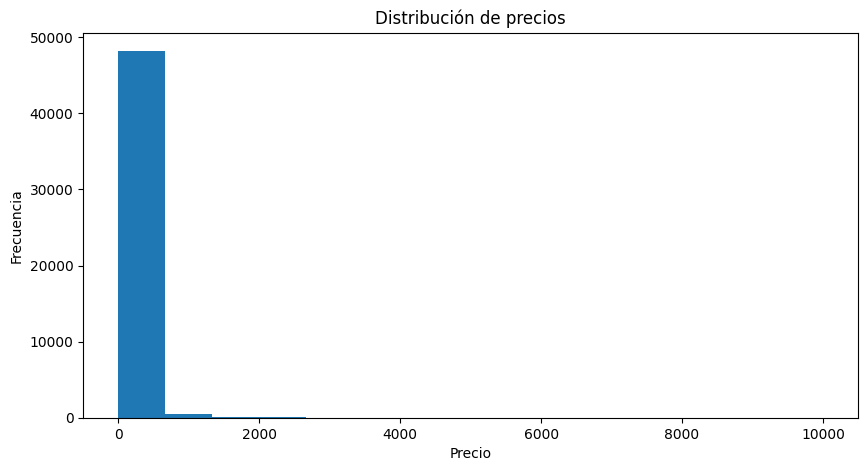

In [25]:
# 4.1 — Construye un histograma de 'price' con .plot(kind='hist').
# Elige un número de bins que te parezca razonable y comenta por qué lo elegiste.
df['price'].plot(kind='hist', bins=15, figsize=(10, 5))

plt.title('Distribución de precios')
plt.xlabel('Precio')
plt.ylabel('Frecuencia')
plt.show()

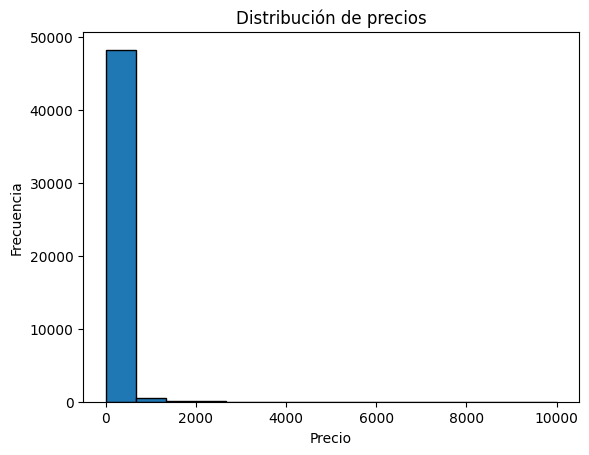

In [26]:
# 4.2 — Construye el mismo histograma con matplotlib.pyplot directamente (plt.hist()),
# agregando título y etiquetas en los ejes.
import matplotlib.pyplot as plt

plt.hist(df['price'], bins=15, edgecolor='black')

plt.title('Distribución de precios')
plt.xlabel('Precio')
plt.ylabel('Frecuencia')

plt.show()



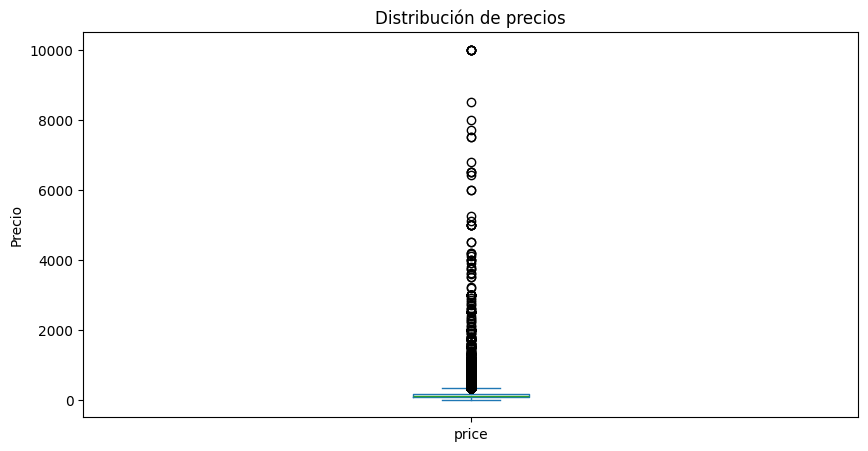

In [27]:
# 4.3 — Construye un boxplot de 'price' (con .plot(kind='box') o plt.boxplot()).
df['price'].plot(kind='box', figsize=(10, 5))

plt.title('Distribución de precios')
plt.ylabel('Precio')
plt.show()


**4.4 — Conclusión (responde aquí en Markdown):**

Describe lo que observas en el histograma y el boxplot de `price`. ¿Los outliers son visibles en ambos gráficos? ¿En cuál se distinguen mejor? Relaciona tu respuesta con los valores de asimetría y curtosis que calculaste en la Actividad 3.
l
_Tu respuesta: os outliers también son claramente visibles, ya que aparecen numerosos puntos por encima del límite superior. El boxplot permite distinguirlos con mayor claridad, porque muestra directamente qué valores se consideran atípicos respecto al rango intercuartílico (IQR).

Esto coincide con los valores de asimetría y curtosis calculados en la Actividad 3: una asimetría positiva indica la cola hacia la derecha, mientras que una curtosis elevada refleja la presencia de colas pesadas y valores extremos.

---
## Reflexión final (10 pts)

Con base en las 4 actividades anteriores: si tuvieras que explicarle a alguien que no ha visto este dataset por qué el precio "promedio" de $152.72 puede ser engañoso, ¿qué le dirías, usando al menos dos de las medidas que calculaste?

_Tu respuesta: Le explicaría lo siguiente:El precio promedio de $152.72 puede ser engañoso porque la distribución de price no es simétrica: está muy sesgada hacia la derecha y tiene muchos valores extremos. Por ejemplo, la mediana representa mejor el precio típico que la media cuando hay valores muy altos. Además, la asimetría positiva que calculamos confirma que existen precios altos que elevan el promedio. La curtosis elevada también indica la presencia de valores extremos.

---
## Rúbrica de evaluación

| Actividad | Puntos | Criterio |
|---|---|---|
| 1. Tendencia central | 20 | Calcula correctamente media, mediana, moda; la conclusión (1.2) conecta la divergencia con la presencia de outliers, no es una afirmación aislada |
| 2. Dispersión | 20 | Calcula correctamente rango, varianza, std, IQR; la conclusión (2.2) justifica cuál medida es más representativa con evidencia del propio cálculo |
| 3. Forma | 20 | Calcula correctamente asimetría y curtosis; la conclusión (3.2) compara explícitamente contra el caso de `Income` visto en clase |
| 4. Visualización | 30 | Histograma y boxplot correctamente construidos (ambas versiones: `.plot()` y `plt.`); código comentado justificando decisiones (ej. bins); la conclusión (4.4) conecta lo visual con los estadísticos de la Actividad 3 |
| Reflexión final | 10 | La explicación usa al menos dos medidas concretas, no es una respuesta genérica |
| **Total** | **100** | |